# Pre Procesamiento

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:

# ── 1. CARGAR DATASET ORIGINAL ───────────────────────────────
df = pd.read_excel('Dry_Bean_Dataset.xlsx')
print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset cargado: 13611 filas × 17 columnas


In [3]:

# ── 2. ELIMINAR DUPLICADOS ───────────────────────────────────
n_before = len(df)
df = df.drop_duplicates()
print(f"Duplicados eliminados: {n_before - len(df)}")
print(f"Filas restantes: {len(df)}")

Duplicados eliminados: 68
Filas restantes: 13543


In [4]:

# ── 3. VERIFICAR NULOS ───────────────────────────────────────
assert df.isnull().sum().sum() == 0, "Hay valores nulos — revisar"
print("✓ Sin valores nulos")

✓ Sin valores nulos


In [5]:

# ── 4. SEPARAR FEATURES Y TARGET ────────────────────────────
features = [c for c in df.columns if c != 'Class']
X = df[features].copy()
y = df['Class'].copy()

print(f"\nFeatures ({len(features)}): {features}")
print(f"Clases ({y.nunique()}): {sorted(y.unique())}")


Features (16): ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
Clases (7): ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [6]:

# ── 5. ESTANDARIZACIÓN (StandardScaler) ─────────────────────
# Justificación: GMM usa distancias euclidianas y matrices de covarianza.
# Variables con escalas muy distintas (Area ~40k vs Eccentricity ~0.7)
# distorsionan las gaussianas. StandardScaler normaliza a media 0 y std 1.
# Se prefiere sobre RobustScaler porque el dataset no tiene outliers extremos
# (verificado en EDA) y StandardScaler es estándar para GMM.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("\n✓ StandardScaler aplicado")
print(f"Media post-scaling (debe ser ~0): {X_scaled_df.mean().mean():.6f}")
print(f"Std post-scaling (debe ser ~1):   {X_scaled_df.std().mean():.4f}")


✓ StandardScaler aplicado
Media post-scaling (debe ser ~0): 0.000000
Std post-scaling (debe ser ~1):   1.0000


In [7]:

# ── 6. ENCODING DE VARIABLE TARGET ──────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nEncoding de clases:")
for i, clase in enumerate(le.classes_):
    print(f"  {clase} → {i}")


Encoding de clases:
  BARBUNYA → 0
  BOMBAY → 1
  CALI → 2
  DERMASON → 3
  HOROZ → 4
  SEKER → 5
  SIRA → 6


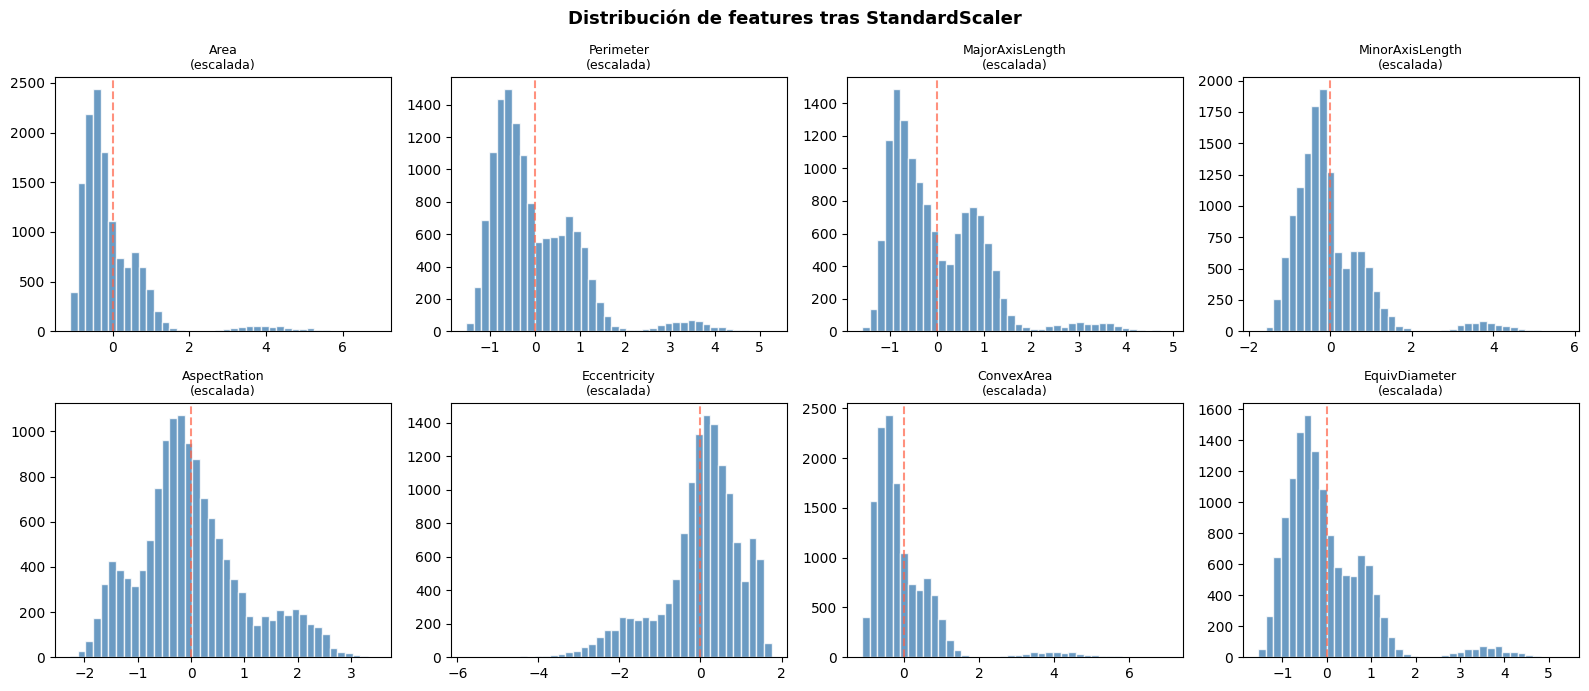

✓ Guardado: fig_07_post_scaling.png


In [8]:

# ── 7. VERIFICACIÓN VISUAL: distribución post-scaling ────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, feat in enumerate(features[:8]):
    axes[i].hist(X_scaled_df[feat], bins=40, color='steelblue', 
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feat}\n(escalada)', fontsize=9)
    axes[i].axvline(0, color='tomato', linestyle='--', alpha=0.7)
plt.suptitle('Distribución de features tras StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_post_scaling.png', dpi=150)
plt.show()
print("✓ Guardado: fig_07_post_scaling.png")

In [9]:

# ── 8. GUARDAR DATASET PROCESADO ────────────────────────────
os.makedirs('data/processed', exist_ok=True)

# Guardar X escalado + y encoded juntos
df_clean = X_scaled_df.copy()
df_clean['Class'] = y_encoded
df_clean['Class_name'] = y.values

df_clean.to_csv('data/processed/dataset_clean.csv', index=False)
print(f"\n✓ Dataset guardado en: data/processed/dataset_clean.csv")
print(f"  Shape final: {df_clean.shape}")

# Guardar también el label encoder mapping
import json
mapping = {int(i): str(c) for i, c in enumerate(le.classes_)}
with open('data/processed/class_mapping.json', 'w') as f:
    json.dump(mapping, f, indent=2)
print("✓ Mapping de clases guardado en: ../data/processed/class_mapping.json")
print(f"  Mapping: {mapping}")

print("\n" + "=" * 50)
print("PREPROCESAMIENTO COMPLETADO")
print("=" * 50)


✓ Dataset guardado en: data/processed/dataset_clean.csv
  Shape final: (13543, 18)
✓ Mapping de clases guardado en: ../data/processed/class_mapping.json
  Mapping: {0: 'BARBUNYA', 1: 'BOMBAY', 2: 'CALI', 3: 'DERMASON', 4: 'HOROZ', 5: 'SEKER', 6: 'SIRA'}

PREPROCESAMIENTO COMPLETADO
